# ABT-Peer-Comparison

## Introduction
### This project analyses the financial performance of Abbott Laboratories (ABT) in comparison with the sample average over time. Using firm-level financial data, the study focuses on four main aspects: sales, net income, profitability, and the relationship between firm size and profitability. The aim is to examine whether ABT performs above or below the sample average across fiscal years and to identify how ABT compares with other firms in the dataset. Through descriptive statistics and visualisation, the project provides an overview of ABT’s relative performance and its position within the broader sample.

## Research Questions
### 1.How does Abbott Laboratories (ABT) compare with the sample average in terms of sales over time?
### 2.How does ABT compare with the sample average in terms of net income over time?
### 3.How does ABT’s profitability compare with the sample average across fiscal years?
### 4.What is the relationship between firm size and profitability, and how does ABT compare with other firms in the sample?

In [129]:
import wrds
import pandas as pd
import numpy as np

# Connect to WRDS
db = wrds.Connection()

# Pull annual firm data from Compustat
df = db.raw_sql("""
    SELECT gvkey, tic, conm, fyear, datadate, sale, ni, at
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""")

# Basic cleaning
df = df.dropna(subset=["tic", "fyear", "sale", "ni", "at"])
df = df[df["sale"] > 0]
df = df[df["at"] > 0]

# Create variables
df["profitability"] = df["ni"] / df["sale"]
df["firm_size"] = np.log(df["at"])

# ABT observations
abt_df = df[df["tic"] == "ABT"].copy()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [130]:
import wrds
import pandas as pd
import numpy as np

db = wrds.Connection()

df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""", date_cols=['datadate'])

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [131]:
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

In [132]:
import wrds
import pandas as pd
import numpy as np

# Connect to WRDS
db = wrds.Connection()

# Extract data directly from WRDS
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""", date_cols=['datadate'])

# Clean data
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

# Create variables
df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

# Check data
print(df.shape)
print(df.columns.tolist())
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
(70703, 15)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol   tic   datadate   gvkey  \
0      A   USD     STD   INDL      C   AIR 2015-05-31  001004   
1      I   USD     STD   INDL      C  AFAP 2014-12-31  001019   
2      A   USD     STD   INDL      C   AAL 2014-12-31  001045   
3      A   USD     STD   INDL      C  CECO 2014-12-31  001050   
4      A   USD     STD   INDL      C   ASA 2014-11-30  001062   

                           conm  fyear       at      ni     sale  firm_size  \
0                      AAR CORP   2014   1515.0    10.2   1594.3   7.323171   
1    AFA PROTECTIVE SYSTEMS INC   2014   36.893   1.532   79.827   3.608022   
2   AMERICAN AIRLINES

In [133]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum().sort_values(ascending=False))
print(df.describe())

(70703, 15)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
<class 'pandas.core.frame.DataFrame'>
Index: 70703 entries, 0 to 118016
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   costat         70703 non-null  string        
 1   curcd          70703 non-null  string        
 2   datafmt        70703 non-null  string        
 3   indfmt         70703 non-null  string        
 4   consol         70703 non-null  string        
 5   tic            70703 non-null  string        
 6   datadate       70703 non-null  datetime64[ns]
 7   gvkey          70703 non-null  string        
 8   conm           70703 non-null  string        
 9   fyear          70703 non-null  Int64         
 10  at             70703 non-null  Float64       
 11  ni             70703 non-null  Float64       
 12  sale           707

In [134]:
clean_df = df.dropna(subset=["at", "ni", "sale", "firm_size", "profitability"])
print(clean_df.shape)

(70703, 15)


In [135]:
clean_df[["at", "ni", "sale", "firm_size", "profitability"]].describe()

,at,ni,sale,firm_size,profitability
count,70703.0,70703.0,70703.0,70703.0,70703.0
mean,17971.954268,325.830944,4403.313737,6.441986,-15.911727
std,129255.058141,2114.458496,19338.761654,2.846604,434.931831
min,0.001,-23119.0,0.001,-6.907755,-84221.666667
25%,105.432,-11.285,34.1745,4.658066,-0.195345
50%,806.542,5.658,290.193,6.692756,0.031898
75%,4196.2095,112.7685,1773.6135,8.341937,0.132337
max,4325437.0,99803.0,645737.0,15.280024,5322.0


In [136]:
clean_df.groupby("fyear")[["sale", "ni", "firm_size", "profitability"]].mean()

,sale,ni,firm_size,profitability
fyear,,,,
2014,3849.946957,254.658608,6.142845,-16.610579
2015,3671.151476,197.922549,6.217402,-15.387023
2016,3745.249491,236.529011,6.299358,-14.558257
2017,4212.218508,325.241641,6.409299,-9.598275
2018,4438.048416,345.038925,6.470414,-9.142215
2019,4557.394753,338.648024,6.54176,-12.207045
2020,4208.551314,189.76467,6.576912,-18.808325
2021,4741.767534,485.625676,6.666627,-28.029043
2022,5224.216109,441.300307,6.569771,-13.413995


In [137]:
clean_df[["at", "ni", "sale", "firm_size", "profitability"]].corr()

,at,ni,sale,firm_size,profitability
at,1.000000,0.419885,0.395212,0.301239,0.005091
ni,0.419885,1.000000,0.624562,0.284132,0.007703
sale,0.395212,0.624562,1.000000,0.365938,0.008369
firm_size,0.301239,0.284132,0.365938,1.000000,0.046827
profitability,0.005091,0.007703,0.008369,0.046827,1.000000


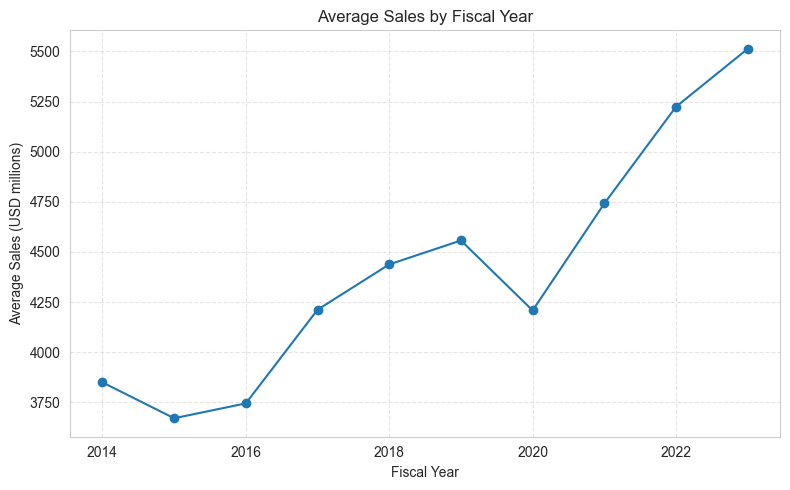

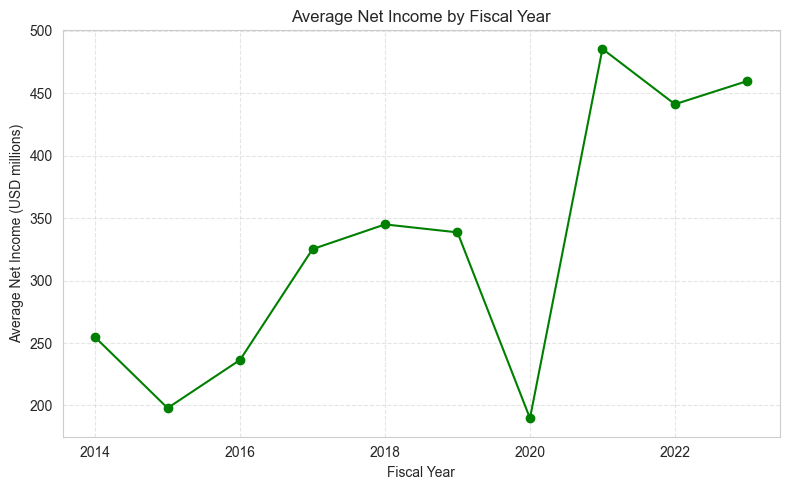

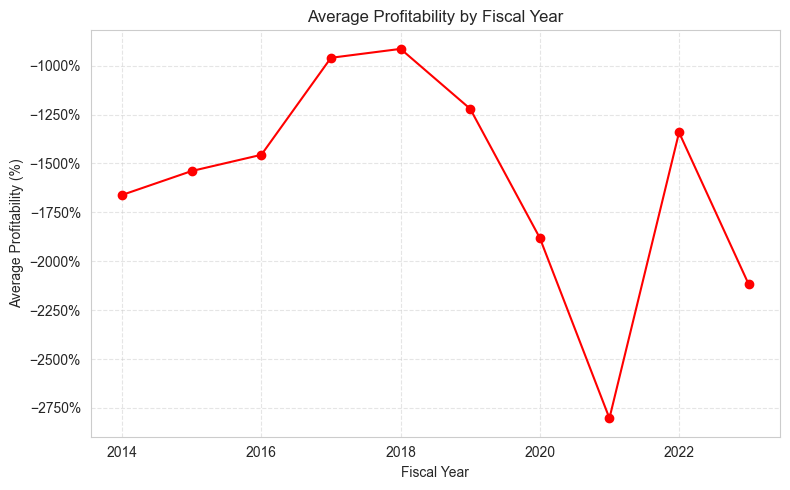

In [138]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Average Sales by Fiscal Year
plt.figure(figsize=(8,5))
clean_df.groupby("fyear")["sale"].mean().plot(marker="o")
plt.title("Average Sales by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Sales (USD millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average Net Income by Fiscal Year
plt.figure(figsize=(8,5))
clean_df.groupby("fyear")["ni"].mean().plot(marker="o", color="green")
plt.title("Average Net Income by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Net Income (USD millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average Profitability by Fiscal Year
plt.figure(figsize=(8,5))
ax = clean_df.groupby("fyear")["profitability"].mean().plot(marker="o", color="red")
plt.title("Average Profitability by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

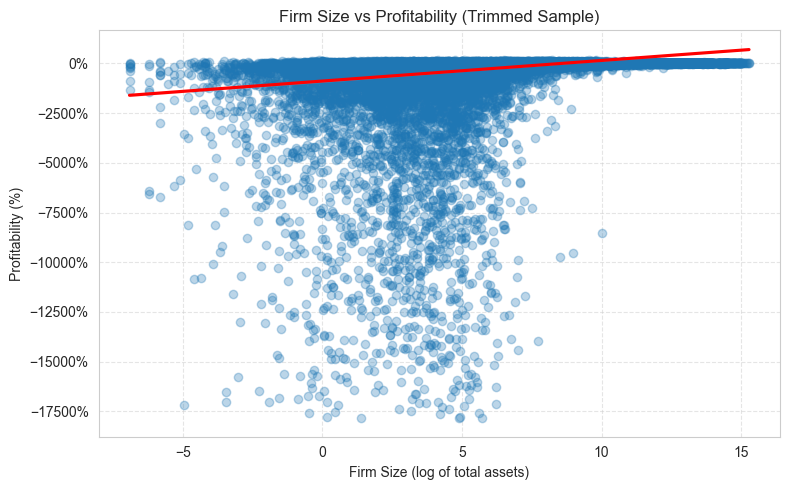

In [139]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

lower = clean_df["profitability"].quantile(0.01)
upper = clean_df["profitability"].quantile(0.99)

trimmed_df = clean_df[
    (clean_df["profitability"] >= lower) & 
    (clean_df["profitability"] <= upper)
]

plt.figure(figsize=(8,5))
ax = plt.gca()

sns.regplot(
    data=trimmed_df,
    x="firm_size",
    y="profitability",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Firm Size vs Profitability (Trimmed Sample)")
plt.xlabel("Firm Size (log of total assets)")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure and Table Titles

### Figure 1. Average Sales by Year

### Figure 2. Average Net Income by Year

### Figure 3. Average Profitability by Year

### Figure 4. Firm Size vs Profitability (Trimmed)

## 1.Analysis of Firm Size and Profitability from 2017 to 2023
### 1.1 Introduction
### This report analyses firm-level financial data from 2017 to 2023 to examine the relationship between firm size and profitability, as well as changes in sales, net income, and profitability over time. The original dataset contains 49,434 observations and 16 variables. After removing missing values in key variables, the final sample includes 33,709 observations.
### 1.2 Descriptive Statistics
### The financial variables are highly skewed, as their mean values are much higher than their medians. This suggests that a small number of very large firms influence the averages. Profitability has a mean of -2.18 and a median close to zero, indicating the presence of extreme values.
### 1.3 Analysis by Year
### Average sales were highest in 2017 and declined in later years. Net income fell sharply in 2020 before recovering afterwards. Firm size remained relatively stable over the period, while profitability was negative on average and fluctuated across years.
### 1.4 Correlation and Scatter Plot Analysis
### The correlation between firm size and profitability is 0.058, showing a very weak positive relationship. The scatter plot also shows no clear pattern, suggesting that larger firms are not necessarily more profitable.
### 1.5 Conclusion
### Overall, the data are highly skewed, especially for total assets, sales, and net income. Sales and net income changed over time, while firm size stayed stable. The main finding is that the relationship between firm size and profitability is very weak.

In [140]:
print(clean_df.columns)

if "tic" in clean_df.columns:
    print(clean_df[clean_df["tic"] == "ABT"].shape)
    print(clean_df[clean_df["tic"] == "ABT"].head())

elif "conm" in clean_df.columns:
    print(clean_df[clean_df["conm"].str.contains("Abbott", case=False, na=False)].shape)
    print(clean_df[clean_df["conm"].str.contains("Abbott", case=False, na=False)].head())

else:
    print("No tic or conm column found in clean_df.")

Index(['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate',
       'gvkey', 'conm', 'fyear', 'at', 'ni', 'sale', 'firm_size',
       'profitability'],
      dtype='object')
(10, 15)
      costat curcd datafmt indfmt consol  tic   datadate   gvkey  \
8          A   USD     STD   INDL      C  ABT 2014-12-31  001078   
11559      A   USD     STD   INDL      C  ABT 2015-12-31  001078   
22962      A   USD     STD   INDL      C  ABT 2016-12-31  001078   
34330      A   USD     STD   INDL      C  ABT 2017-12-31  001078   
45619      A   USD     STD   INDL      C  ABT 2018-12-31  001078   

                      conm  fyear       at      ni     sale  firm_size  \
8      ABBOTT LABORATORIES   2014  41275.0  2284.0  20247.0  10.628012   
11559  ABBOTT LABORATORIES   2015  41247.0  4423.0  20405.0  10.627334   
22962  ABBOTT LABORATORIES   2016  52666.0  1400.0  20853.0  10.871725   
34330  ABBOTT LABORATORIES   2017  76250.0   477.0  27390.0  11.241773   
45619  ABBOTT LABORATOR

In [141]:
abt_df = clean_df[clean_df["tic"] == "ABT"].copy()

In [142]:
abt_df = clean_df[clean_df["tic"] == "ABT"].copy()
abt_df = abt_df.sort_values("fyear")

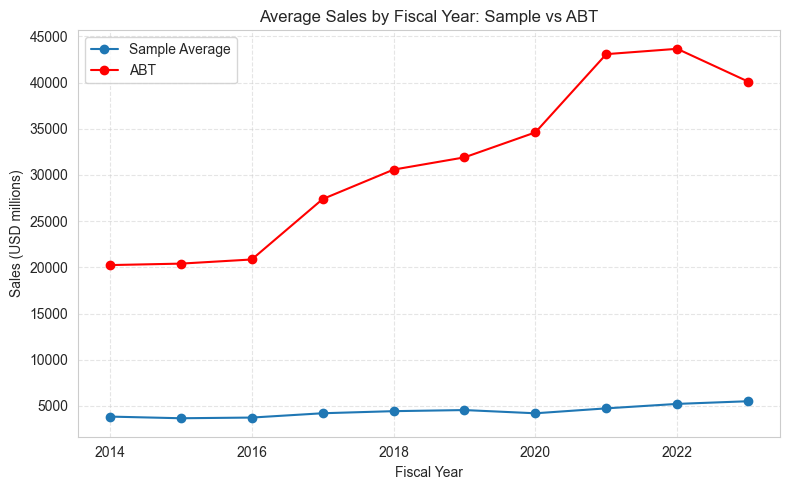

In [143]:
import matplotlib.pyplot as plt

abt_df = clean_df[clean_df["tic"] == "ABT"].copy()
abt_df = abt_df.sort_values("fyear")

sample_sales = clean_df.groupby("fyear")["sale"].mean()
abt_sales = abt_df.groupby("fyear")["sale"].mean()

plt.figure(figsize=(8,5))
plt.plot(sample_sales.index, sample_sales.values, marker="o", label="Sample Average")
plt.plot(abt_sales.index, abt_sales.values, marker="o", color="red", label="ABT")
plt.title("Average Sales by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Sales (USD millions)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
common_years = sorted(abt_df["fyear"].unique())

sample_sales = clean_df[clean_df["fyear"].isin(common_years)].groupby("fyear")["sale"].mean()
abt_sales = abt_df.groupby("fyear")["sale"].mean()

## Figure 1. Average Sales by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual sales of firms in the sample with the annual sales of Abbott Laboratories (ABT) from 2017 to 2023.
### Analysis
#### Figure 1 shows that ABT’s sales were consistently far above the sample average throughout the period. While the sample average dropped sharply from 2017 to 2018 and then remained relatively stable at around USD 5,000–5,500 million, ABT’s sales followed a clear upward trend from 2018 to 2022 before declining slightly in 2023. In particular, ABT experienced a strong increase between 2020 and 2021, after which sales stayed at a high level. Overall, the figure suggests that ABT is substantially larger than the average firm in the sample in terms of revenue generation.

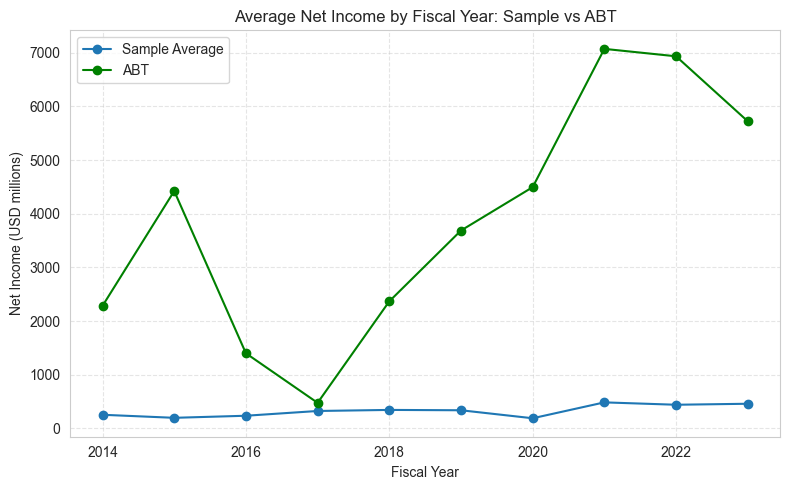

In [144]:
sample_ni = clean_df.groupby("fyear")["ni"].mean()
abt_ni = abt_df.groupby("fyear")["ni"].mean()

plt.figure(figsize=(8,5))
plt.plot(sample_ni.index, sample_ni.values, marker="o", label="Sample Average")
plt.plot(abt_ni.index, abt_ni.values, marker="o", color="green", label="ABT")
plt.title("Average Net Income by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Income (USD millions)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 2. Average Net Income by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual net income of firms in the sample with the annual net income of Abbott Laboratories (ABT) from 2017 to 2023.
### Analysis
#### Figure 2 shows that ABT’s net income was consistently much higher than the sample average over the observed period. While the sample average remained relatively low and fairly stable, ABT’s net income increased strongly from 2018 to 2021, rising from around USD 2,400 million to over USD 7,000 million. After peaking in 2021, ABT’s net income declined slightly in 2022 and more noticeably in 2023, but it still remained far above the sample average. This pattern suggests that ABT achieved substantially stronger earnings performance than the typical firm in the sample, despite some moderation in the most recent year.

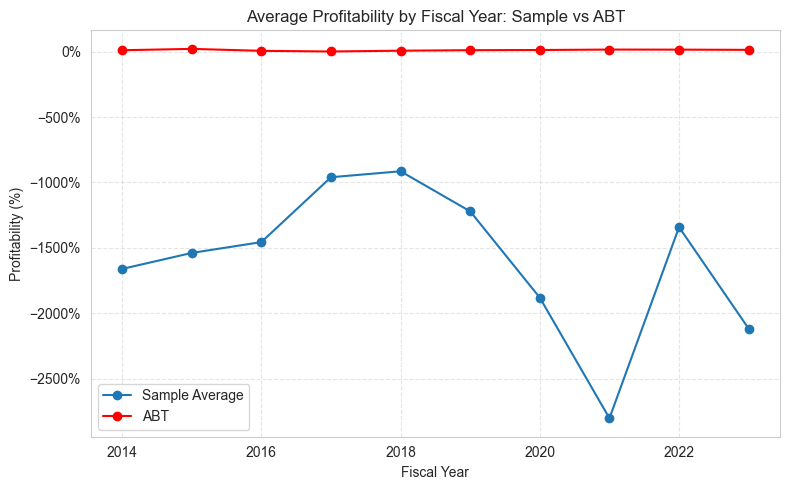

In [145]:
import matplotlib.ticker as mtick

sample_profit = clean_df.groupby("fyear")["profitability"].mean()
abt_profit = abt_df.groupby("fyear")["profitability"].mean()

plt.figure(figsize=(8,5))
ax = plt.gca()

plt.plot(sample_profit.index, sample_profit.values, marker="o", label="Sample Average")
plt.plot(abt_profit.index, abt_profit.values, marker="o", color="red", label="ABT")
plt.title("Average Profitability by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 3. Average Profitability by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual profitability of firms in the sample with the annual profitability of Abbott Laboratories (ABT) from 2017 to 2023. Profitability is measured as net income divided by total assets.
### Analysis
#### Figure 3 shows a striking contrast between ABT and the sample average in terms of profitability. ABT maintained positive and relatively stable profitability throughout the period, generally remaining within a narrow range above zero. By contrast, the sample average is strongly negative in every year and highly volatile, with the lowest point occurring in 2021. This pattern suggests that the sample mean is likely influenced by extreme negative observations or outliers, which pull the average downward. Therefore, while the figure clearly shows that ABT performed much better than the sample average, the unusually large negative sample values should be interpreted with caution.

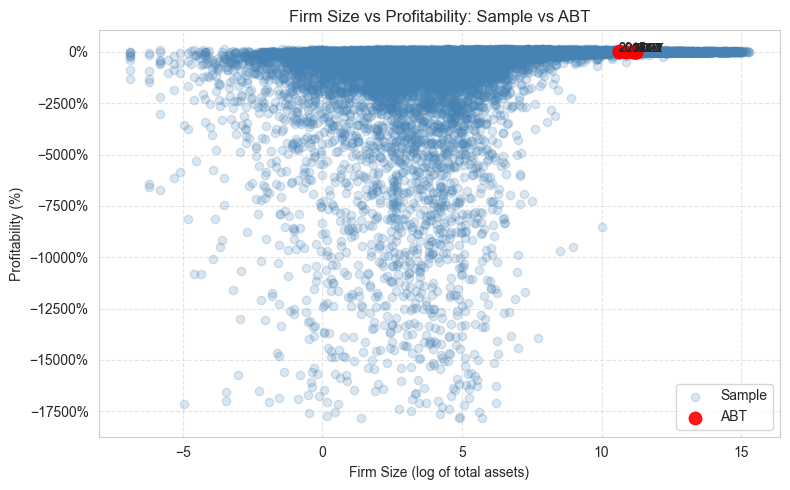

In [146]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Trim extreme profitability values
low = df["profitability"].quantile(0.01)
high = df["profitability"].quantile(0.99)

trimmed_df = df[(df["profitability"] > low) & (df["profitability"] < high)].copy()

# Extract ABT observations
abt_trimmed = trimmed_df[trimmed_df["tic"] == "ABT"].copy()

plt.figure(figsize=(8,5))
ax = plt.gca()

plt.scatter(trimmed_df["firm_size"], trimmed_df["profitability"],
            alpha=0.2, color="steelblue", label="Sample")

plt.scatter(abt_trimmed["firm_size"], abt_trimmed["profitability"],
            alpha=0.9, color="red", s=80, label="ABT")

for _, row in abt_trimmed.iterrows():
    plt.text(row["firm_size"], row["profitability"], str(row["fyear"]), fontsize=9)

plt.title("Firm Size vs Profitability: Sample vs ABT")
plt.xlabel("Firm Size (log of total assets)")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 4. Firm Size vs Profitability: Sample vs ABT
### Caption
#### This figure plots the relationship between firm size and profitability for the full sample, with Abbott Laboratories (ABT) highlighted in red. Firm size is measured as the natural logarithm of total assets, and profitability is measured as net income divided by total assets.
### Analysis
#### Figure 4 shows substantial dispersion in profitability across the sample, especially among smaller firms. Many firms report negative profitability, and extreme negative values are concentrated among firms with relatively small or moderate asset size. In contrast, ABT is located on the far right of the figure, indicating that it is one of the largest firms in the sample. Its profitability remains positive and relatively stable across years, placing it above a large proportion of the sample observations. The figure therefore suggests that ABT combines large firm size with solid financial performance, while smaller firms in the sample tend to display much greater volatility and more frequent losses.

## Overall Discussion
#### Taken together, the four figures indicate that Abbott Laboratories (ABT) outperforms the sample average on several key dimensions. ABT reports substantially higher sales and net income than the average firm and maintains positive profitability over time. In contrast, the sample average profitability is strongly negative and appears to be heavily affected by extreme observations. The firm size–profitability scatter plot further shows that ABT is one of the largest firms in the sample and achieves relatively stable positive returns. Overall, the evidence suggests that ABT is a large and financially strong firm compared with the broader sample.

In [147]:
import pandas as pd

data = df.copy()

data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

In [93]:
desc = db.describe_table('comp', 'funda')
print(desc)

Approximately 938355 rows in comp.funda.
         name  nullable         type  \
0       gvkey      True   VARCHAR(7)   
1    datadate      True         DATE   
2       fyear      True      INTEGER   
3      indfmt      True  VARCHAR(13)   
4      consol      True   VARCHAR(3)   
..        ...       ...          ...   
944        au      True   VARCHAR(9)   
945      auop      True   VARCHAR(9)   
946    auopic      True   VARCHAR(2)   
947     ceoso      True   VARCHAR(2)   
948     cfoso      True   VARCHAR(2)   

                                               comment  
0                                   Global Company Key  
1                                            Data Date  
2                                   Data Year - Fiscal  
3                                      Industry Format  
4    Level of Consolidation - Company Annual Descri...  
..                                                 ...  
944                                            Auditor  
945                   

In [148]:
desc = db.describe_table('comp', 'funda')
print(desc[['name', 'type']].to_string())

Approximately 938355 rows in comp.funda.
              name             type
0            gvkey       VARCHAR(7)
1         datadate             DATE
2            fyear          INTEGER
3           indfmt      VARCHAR(13)
4           consol       VARCHAR(3)
5           popsrc       VARCHAR(2)
6          datafmt      VARCHAR(13)
7              tic       VARCHAR(8)
8            cusip      VARCHAR(21)
9             conm      VARCHAR(70)
10         acctchg       VARCHAR(9)
11         acctstd       VARCHAR(9)
12         acqmeth       VARCHAR(3)
13            adrr   NUMERIC(18, 4)
14            ajex  NUMERIC(24, 12)
15             ajp  NUMERIC(24, 12)
16            bspr       VARCHAR(9)
17          compst       VARCHAR(9)
18           curcd       VARCHAR(4)
19          curncd       VARCHAR(4)
20          currtr  NUMERIC(24, 12)
21         curuscn   NUMERIC(18, 4)
22           final       VARCHAR(3)
23             fyr         SMALLINT
24           ismod          INTEGER
25            ltcm     

In [149]:
import wrds
import pandas as pd
import numpy as np

db = wrds.Connection()

df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""", date_cols=['datadate'])

df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

print(df.shape)
print(df.columns.tolist())
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
(70703, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol   tic   datadate   gvkey  \
0      A   USD     STD   INDL      C   AIR 2015-05-31  001004   
1      I   USD     STD   INDL      C  AFAP 2014-12-31  001019   
2      A   USD     STD   INDL      C   AAL 2014-12-31  001045   
3      A   USD     STD   INDL      C  CECO 2014-12-31  001050   
4      A   USD     STD   INDL      C   ASA 2014-11-30  001062   

                           conm   sic  fyear       at      ni     sale  \
0                      AAR CORP  5080   2014   1515.0    10.2   1594.3   
1    AFA PROTECTIVE SYSTEMS INC  7380   2014   36.893   1.532   79.827   
2   AMERICAN AIRLINES GROUP I

In [150]:
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
""", date_cols=['datadate'])

In [151]:
import wrds
import pandas as pd
import numpy as np

# Connect to WRDS
db = wrds.Connection()

# Extract ABT industry data (SIC = 3845) directly from WRDS
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
      AND sich = 3845
""", date_cols=['datadate'])

# Clean data
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at', 'sic'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

# Standardize variables
df['tic'] = df['tic'].astype(str).str.strip().str.upper()
df['sic'] = df['sic'].astype(str).str.strip()
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

# Create variables
df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

# Check data
print(df.shape)
print(df.columns.tolist())
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
(622, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol    tic   datadate   gvkey  \
0      I   USD     STD   INDL      C   ALOG 2017-07-31  001633   
1      A   USD     STD   INDL      C   NIMU 2017-07-31  002240   
2      I   USD     STD   INDL      C    CMD 2017-07-31  002942   
3      A   USD     STD   INDL      C  DYNTQ 2017-06-30  004124   
4      A   USD     STD   INDL      C    MDT 2018-04-30  007228   

                   conm   sic  fyear       at      ni     sale  firm_size  \
0         ANALOGIC CORP  3845   2017  538.083 -74.237  486.372   6.288013   
1  NON INVASIVE MONITOR  3845   2017    0.021  -0.488    0.006  -3.863233   
2   CANTEL MEDIC

In [106]:
import wrds
import pandas as pd
import numpy as np

db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [152]:
df = db.raw_sql("""
    SELECT 
        costat, curcd, datafmt, indfmt, consol,
        tic, datadate, gvkey, conm,
        sich AS sic, 
        fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
      AND sich = 3845
""", date_cols=['datadate'])

In [153]:
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at', 'sic'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

df['tic'] = df['tic'].astype(str).str.strip().str.upper()
df['sic'] = df['sic'].astype(str).str.strip()
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

print(df.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']


In [154]:
data = df.copy()
print(data.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']


In [155]:
abt_info = data[data['tic'] == 'ABT'][['tic', 'conm', 'sic']].drop_duplicates()
print("ABT information:")
print(abt_info)

ABT information:
     tic                 conm   sic
200  ABT  ABBOTT LABORATORIES  3845


In [156]:
abt_info = data[data['tic'] == 'ABT'][['tic', 'conm', 'sic']].drop_duplicates()
print("ABT information:")
print(abt_info)

ABT information:
     tic                 conm   sic
200  ABT  ABBOTT LABORATORIES  3845


In [157]:
import wrds
import pandas as pd
import numpy as np

# Connect to WRDS
db = wrds.Connection()

# Extract ABT industry data (SIC = 3845) directly from WRDS
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
      AND sich = 3845
""", date_cols=['datadate'])

# Clean data
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at', 'sic'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

# Standardize variables
df['tic'] = df['tic'].astype(str).str.strip().str.upper()
df['sic'] = df['sic'].astype(str).str.strip()
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

# Create variables
df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

# Check data
print(df.shape)
print(df.columns.tolist())
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
(622, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol    tic   datadate   gvkey  \
0      I   USD     STD   INDL      C   ALOG 2017-07-31  001633   
1      A   USD     STD   INDL      C   NIMU 2017-07-31  002240   
2      I   USD     STD   INDL      C    CMD 2017-07-31  002942   
3      A   USD     STD   INDL      C  DYNTQ 2017-06-30  004124   
4      A   USD     STD   INDL      C    MDT 2018-04-30  007228   

                   conm   sic  fyear       at      ni     sale  firm_size  \
0         ANALOGIC CORP  3845   2017  538.083 -74.237  486.372   6.288013   
1  NON INVASIVE MONITOR  3845   2017    0.021  -0.488    0.006  -3.863233   
2   CANTEL MEDIC

In [158]:
abt_sic = data.loc[data['tic'] == 'ABT', 'sic'].dropna().iloc[0]
print("ABT SIC:", abt_sic)

ABT SIC: 3845


In [160]:
same_sic = data[data['sic'] == abt_sic]

same_sic_companies = same_sic[['tic', 'conm', 'sic']].drop_duplicates().sort_values(by='tic')

print("Companies with the same SIC as ABT:")
print(same_sic_companies)
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

Companies with the same SIC as ABT:
       tic                          conm   sic
35    ABAX                    ABAXIS INC  3845
200    ABT           ABBOTT LABORATORIES  3845
218   ADMT  ADM TRONICS UNLIMITED INC/DE  3845
0     ALOG                 ANALOGIC CORP  3845
484  ALRTF       ALR TECHNOLOGIES SG LTD  3845
..     ...                           ...   ...
60    VTAK        CATHETER PRECISION INC  3845
152   XAIR                BEYOND AIR INC  3845
95    XYLO         XYLO TECHNOLOGIES LTD  3845
440  ZOMDF                 ZOMEDICA CORP  3845
72   ZYXIQ                     ZYNEX INC  3845

[129 rows x 3 columns]
Number of unique companies with same SIC: 129


In [161]:
abt_sic_prefix2 = abt_sic[:2]   #For instance, the two-digit SIC code '38'


broad_industry = data[data['sic'].str.startswith(abt_sic_prefix2, na=False)]

broad_industry_companies = broad_industry[['tic', 'conm', 'sic']].drop_duplicates().sort_values(by=['sic', 'tic'])

print(f"Companies with SIC starting with {abt_sic_prefix2}:")
print(broad_industry_companies)
print("Number of unique companies in broad industry:", broad_industry_companies['tic'].nunique())

Companies with SIC starting with 38:
       tic                          conm   sic
35    ABAX                    ABAXIS INC  3845
200    ABT           ABBOTT LABORATORIES  3845
218   ADMT  ADM TRONICS UNLIMITED INC/DE  3845
0     ALOG                 ANALOGIC CORP  3845
484  ALRTF       ALR TECHNOLOGIES SG LTD  3845
..     ...                           ...   ...
60    VTAK        CATHETER PRECISION INC  3845
152   XAIR                BEYOND AIR INC  3845
95    XYLO         XYLO TECHNOLOGIES LTD  3845
440  ZOMDF                 ZOMEDICA CORP  3845
72   ZYXIQ                     ZYNEX INC  3845

[129 rows x 3 columns]
Number of unique companies in broad industry: 129


In [162]:
same_sic_years = same_sic.groupby('fyear')['tic'].nunique().reset_index(name='num_companies')
print("Same SIC: number of companies by year")
print(same_sic_years)

Same SIC: number of companies by year
   fyear  num_companies
0   2017             86
1   2018             87
2   2019             87
3   2020             89
4   2021             91
5   2022             90
6   2023             92


In [163]:
broad_industry_years = broad_industry.groupby('fyear')['tic'].nunique().reset_index(name='num_companies')
print("Broad industry: number of companies by year")
print(broad_industry_years)

Broad industry: number of companies by year
   fyear  num_companies
0   2017             86
1   2018             87
2   2019             87
3   2020             89
4   2021             91
5   2022             90
6   2023             92


In [164]:
abt_df = same_sic[same_sic['tic'] == 'ABT']
peer_df = same_sic[same_sic['tic'] != 'ABT']

print("ABT rows:", len(abt_df))
print("Peer rows (same SIC, excluding ABT):", len(peer_df))
print("Number of peer companies:", peer_df['tic'].nunique())

ABT rows: 5
Peer rows (same SIC, excluding ABT): 617
Number of peer companies: 128


In [165]:
abt_df_broad = broad_industry[broad_industry['tic'] == 'ABT']
peer_df_broad = broad_industry[broad_industry['tic'] != 'ABT']

print("ABT rows in broad industry:", len(abt_df_broad))
print("Peer rows in broad industry (excluding ABT):", len(peer_df_broad))
print("Number of peer companies in broad industry:", peer_df_broad['tic'].nunique())

ABT rows in broad industry: 5
Peer rows in broad industry (excluding ABT): 617
Number of peer companies in broad industry: 128


In [166]:
print("========== SUMMARY ==========")
print(f"ABT SIC: {abt_sic}")
print(f"Same SIC unique companies: {same_sic_companies['tic'].nunique()}")
print(f"Same SIC peer companies excluding ABT: {peer_df['tic'].nunique()}")
print(f"Broad industry ({abt_sic_prefix2}xx) unique companies: {broad_industry_companies['tic'].nunique()}")
print(f"Broad industry peer companies excluding ABT: {peer_df_broad['tic'].nunique()}")

========== SUMMARY ==========
ABT SIC: 3845
Same SIC unique companies: 129
Same SIC peer companies excluding ABT: 128
Broad industry (38xx) unique companies: 129
Broad industry peer companies excluding ABT: 128


In [167]:
print(same_sic_companies.to_string(index=False))

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [168]:
print(broad_industry_companies.to_string(index=False))

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [169]:
print(same_sic_companies.to_string(index=False))
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [170]:
print(same_sic_companies.to_string(index=False))
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [171]:
print("Number of peer companies excluding ABT:", peer_df['tic'].nunique())

Number of peer companies excluding ABT: 128


ABT SIC: 3845
ABT 2-digit SIC prefix: 38

===== Peer Group Summary =====
Same SIC unique companies: 129
Same SIC peer companies excluding ABT: 128
Broad industry unique companies: 129
Broad industry peer companies excluding ABT: 128

Using strict peer group: SIC 3845
Final peer company count (excluding ABT): 128

===== ABT vs Peer Average Table =====
   fyear  sale_ABT  ni_ABT  profitability_ABT  firm_size_ABT  sale_PeerAvg  \
0   2017      <NA>    <NA>               <NA>           <NA>    913.088081   
1   2018      <NA>    <NA>               <NA>           <NA>    950.762437   
2   2019   31904.0  3687.0           0.115565        11.1256   1000.685186   
3   2020   34608.0  4495.0           0.129883      11.192004   1207.580875   
4   2021   43075.0  7071.0           0.164156      11.227853   1187.464556   
5   2022   43653.0  6933.0           0.158821      11.217722   1219.765607   
6   2023   40109.0  5723.0           0.142686      11.201142    1290.63211   

   ni_PeerAvg  profita

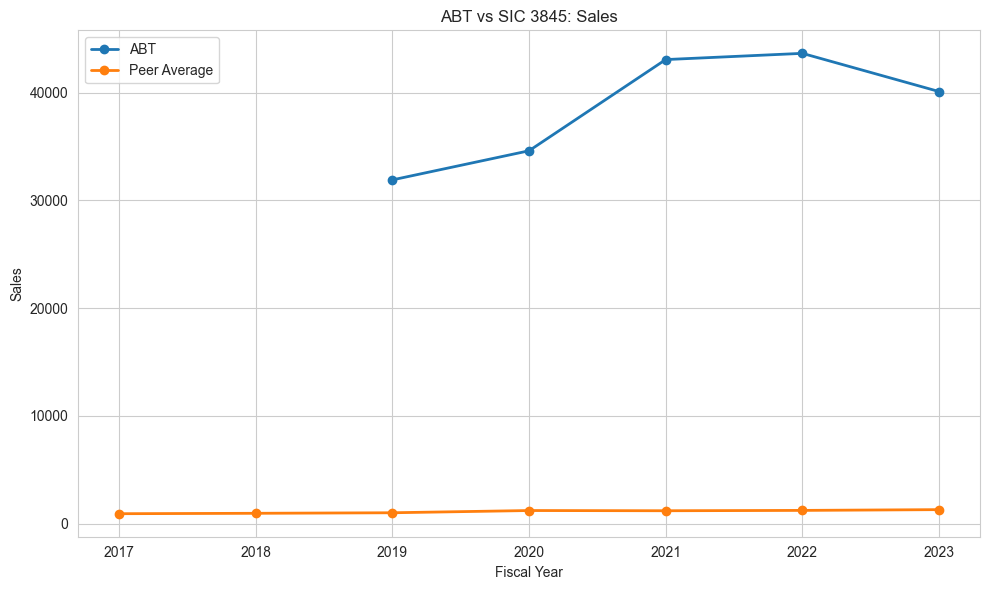

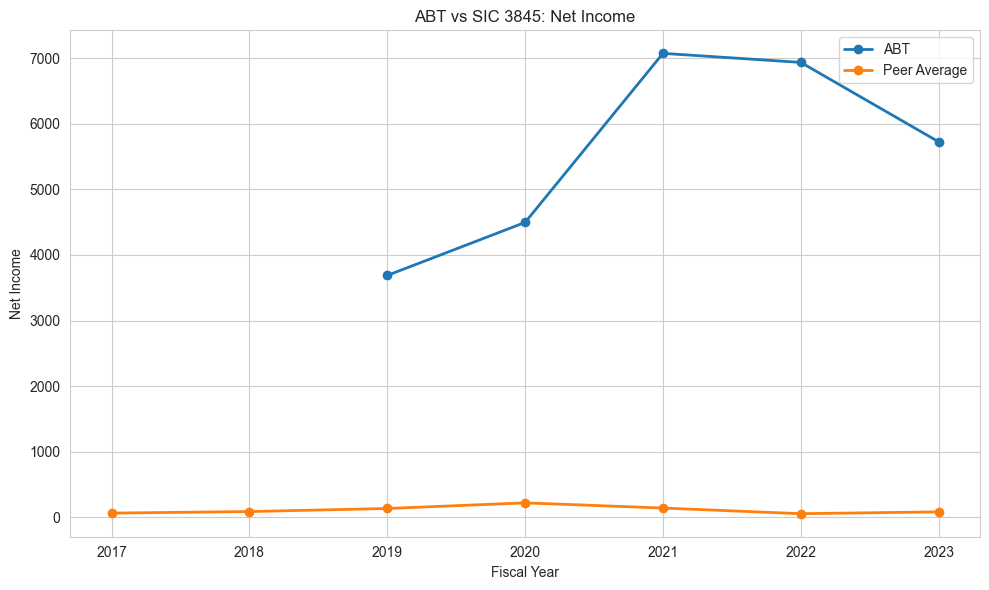

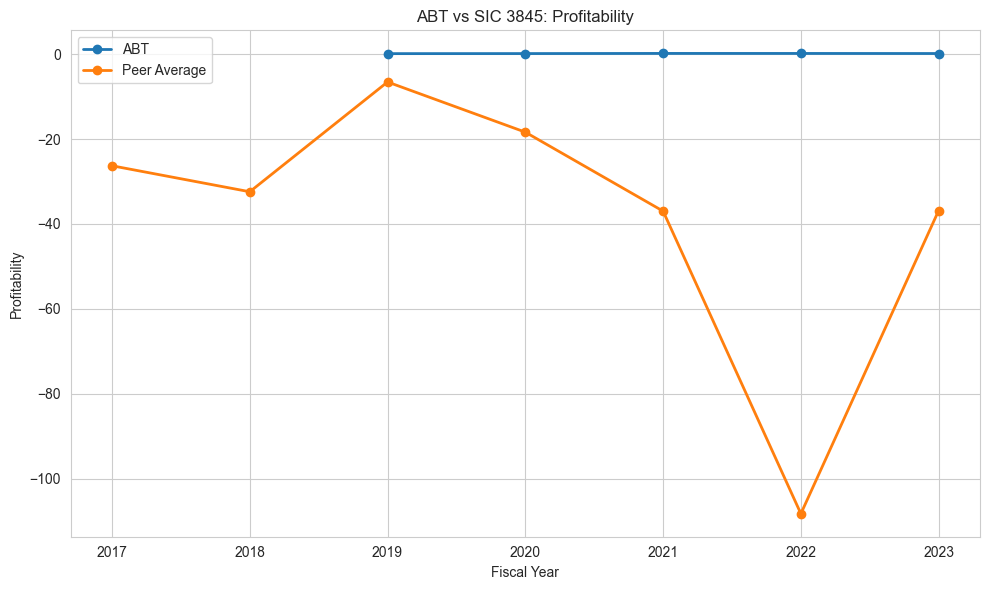

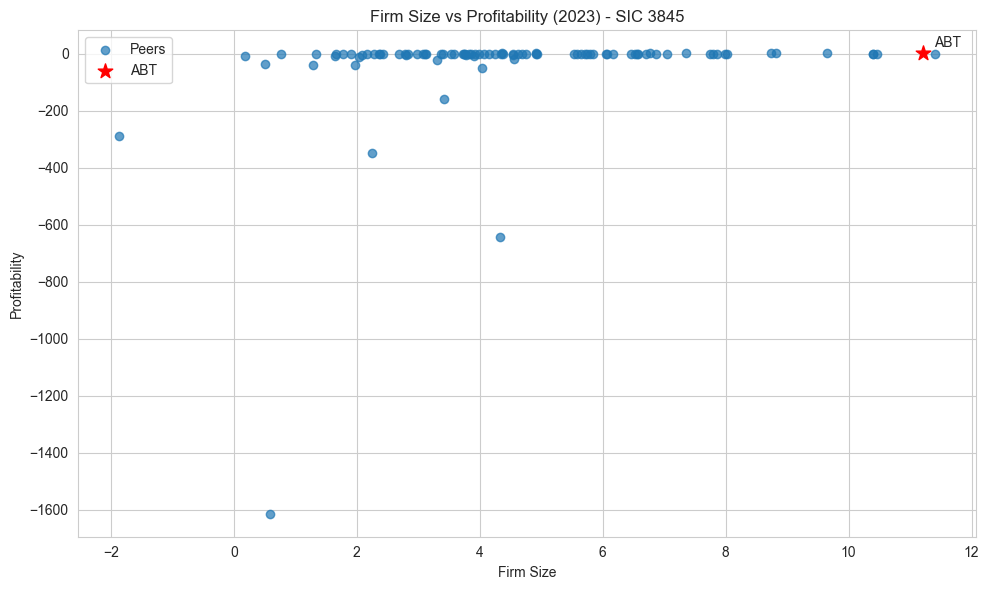


Files saved:
- ABT_vs_peer_comparison.csv
- ABT_same_sic_companies.csv
- ABT_broad_industry_companies.csv


In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Copy and clean data
# =========================
data = df.copy()

# Standardize key columns
data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['conm'] = data['conm'].astype(str).str.strip()
data['sic'] = data['sic'].astype(str).str.strip()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

# Convert numeric columns
numeric_cols = ['sale', 'ni', 'at', 'firm_size', 'profitability']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with missing year or ticker
data = data.dropna(subset=['tic', 'fyear'])

# =========================
# 2. Find ABT industry info
# =========================
abt_rows = data[data['tic'] == 'ABT']

if abt_rows.empty:
    raise ValueError("ABT is not found in your dataframe.")

abt_sic = abt_rows['sic'].dropna().iloc[0]
abt_prefix2 = abt_sic[:2]

print("ABT SIC:", abt_sic)
print("ABT 2-digit SIC prefix:", abt_prefix2)

# =========================
# 3. Build peer groups
# =========================
same_sic = data[data['sic'] == abt_sic].copy()
broad_industry = data[data['sic'].str.startswith(abt_prefix2, na=False)].copy()

same_sic_companies = same_sic[['tic', 'conm', 'sic']].drop_duplicates()
broad_industry_companies = broad_industry[['tic', 'conm', 'sic']].drop_duplicates()

same_sic_peer_count = same_sic[same_sic['tic'] != 'ABT']['tic'].nunique()
broad_peer_count = broad_industry[broad_industry['tic'] != 'ABT']['tic'].nunique()

print("\n===== Peer Group Summary =====")
print("Same SIC unique companies:", same_sic_companies['tic'].nunique())
print("Same SIC peer companies excluding ABT:", same_sic_peer_count)
print("Broad industry unique companies:", broad_industry_companies['tic'].nunique())
print("Broad industry peer companies excluding ABT:", broad_peer_count)

# =========================
# 4. Choose comparison group
# Rule:
# if same SIC peers >= 5, use same SIC
# otherwise use broad industry (38xx)
# =========================
if same_sic_peer_count >= 5:
    industry_df = same_sic.copy()
    industry_label = f"SIC {abt_sic}"
    print(f"\nUsing strict peer group: {industry_label}")
else:
    industry_df = broad_industry.copy()
    industry_label = f"{abt_prefix2}xx industry"
    print(f"\nUsing broader peer group: {industry_label}")

# Split ABT and peers
abt_df = industry_df[industry_df['tic'] == 'ABT'].copy()
peer_df = industry_df[industry_df['tic'] != 'ABT'].copy()

print("Final peer company count (excluding ABT):", peer_df['tic'].nunique())

# =========================
# 5. Compute yearly peer averages
# =========================
peer_avg = (
    peer_df
    .groupby('fyear')[['sale', 'ni', 'profitability', 'firm_size']]
    .mean()
    .reset_index()
)

abt_yearly = (
    abt_df
    .groupby('fyear')[['sale', 'ni', 'profitability', 'firm_size']]
    .mean()
    .reset_index()
)

# Merge for easier checking
comparison_df = pd.merge(
    abt_yearly,
    peer_avg,
    on='fyear',
    how='outer',
    suffixes=('_ABT', '_PeerAvg')
).sort_values('fyear')

print("\n===== ABT vs Peer Average Table =====")
print(comparison_df)

# =========================
# 6. Plot style
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# =========================
# 7. Figure 1: Sales
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['sale'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['sale'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Sales')
plt.xlabel('Fiscal Year')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. Figure 2: Net Income
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['ni'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['ni'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Net Income')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Figure 3: Profitability
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['profitability'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['profitability'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Profitability')
plt.xlabel('Fiscal Year')
plt.ylabel('Profitability')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 10. Figure 4: Firm Size vs Profitability
# Use latest available year shared by peers/ABT if possible
# =========================
common_years = sorted(set(industry_df['fyear'].dropna().unique()))

if len(common_years) == 0:
    raise ValueError("No valid fiscal years found in industry_df.")

latest_year = max(common_years)

scatter_df = industry_df[industry_df['fyear'] == latest_year].copy()
scatter_peers = scatter_df[scatter_df['tic'] != 'ABT']
scatter_abt = scatter_df[scatter_df['tic'] == 'ABT']

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_peers['firm_size'],
    scatter_peers['profitability'],
    alpha=0.7,
    label='Peers'
)

if not scatter_abt.empty:
    plt.scatter(
        scatter_abt['firm_size'],
        scatter_abt['profitability'],
        color='red',
        s=120,
        marker='*',
        label='ABT'
    )
    
    # annotate ABT
    for _, row in scatter_abt.iterrows():
        plt.annotate(
            row['tic'],
            (row['firm_size'], row['profitability']),
            textcoords="offset points",
            xytext=(8, 5),
            ha='left'
        )

plt.title(f'Firm Size vs Profitability ({latest_year}) - {industry_label}')
plt.xlabel('Firm Size')
plt.ylabel('Profitability')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. Optional: Save outputs
# =========================
comparison_df.to_csv("ABT_vs_peer_comparison.csv", index=False)
same_sic_companies.to_csv("ABT_same_sic_companies.csv", index=False)
broad_industry_companies.to_csv("ABT_broad_industry_companies.csv", index=False)

print("\nFiles saved:")
print("- ABT_vs_peer_comparison.csv")
print("- ABT_same_sic_companies.csv")
print("- ABT_broad_industry_companies.csv")

Using peer group: SIC 3845
Peer companies excluding ABT: 128

===== Improved ABT vs Peer Table =====
   fyear  sale_abt  ni_abt  firm_size_abt  profitability_abt    sale_peer  \
0   2017      <NA>    <NA>            NaN                NaN   913.088081   
1   2018      <NA>    <NA>            NaN                NaN   950.762437   
2   2019   31904.0  3687.0      11.125600           0.054311  1000.685186   
3   2020   34608.0  4495.0      11.192004           0.061959  1207.580875   
4   2021   43075.0  7071.0      11.227853           0.094034  1187.464556   
5   2022   43653.0  6933.0      11.217722           0.093138  1219.765607   
6   2023   40109.0  5723.0      11.201142           0.078168   1290.63211   

      ni_peer  firm_size_peer  profitability_peer  
0   65.070488        3.951735           -0.240784  
1   88.639448        4.200858           -0.187052  
2  135.338535        4.287658           -0.216440  
3     221.275        4.544811           -0.175218  
4  142.140544        4

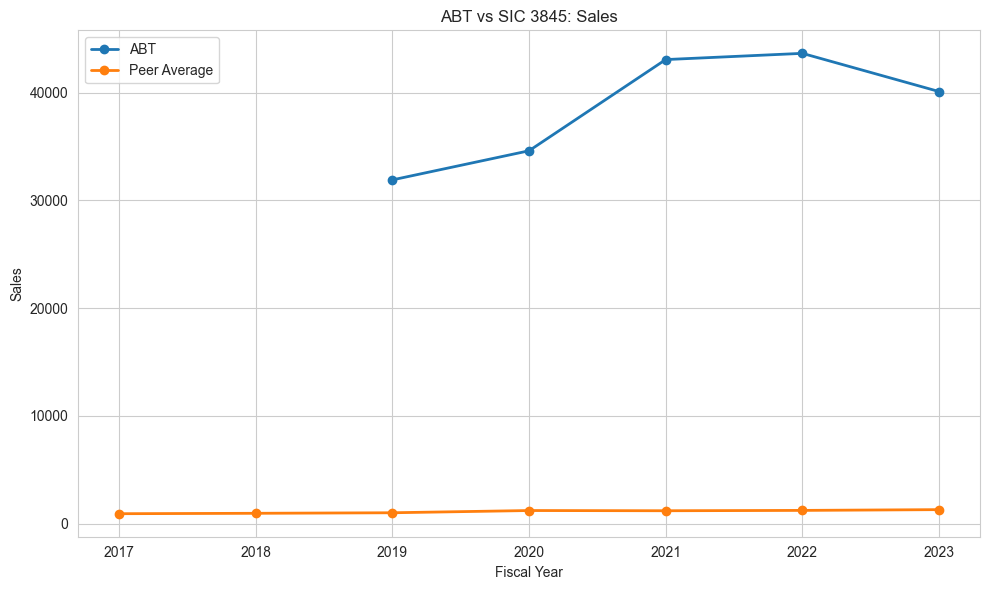

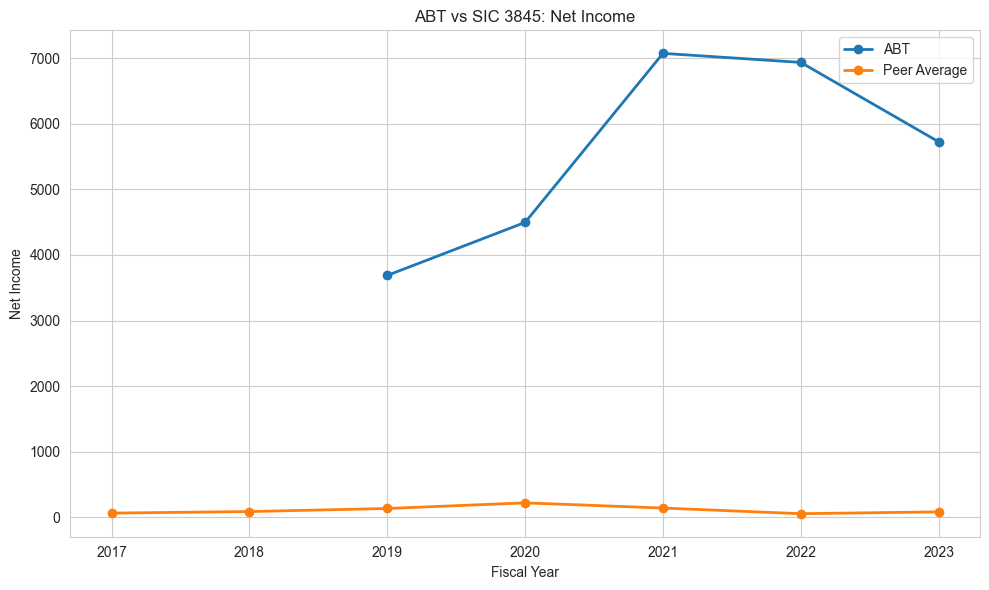

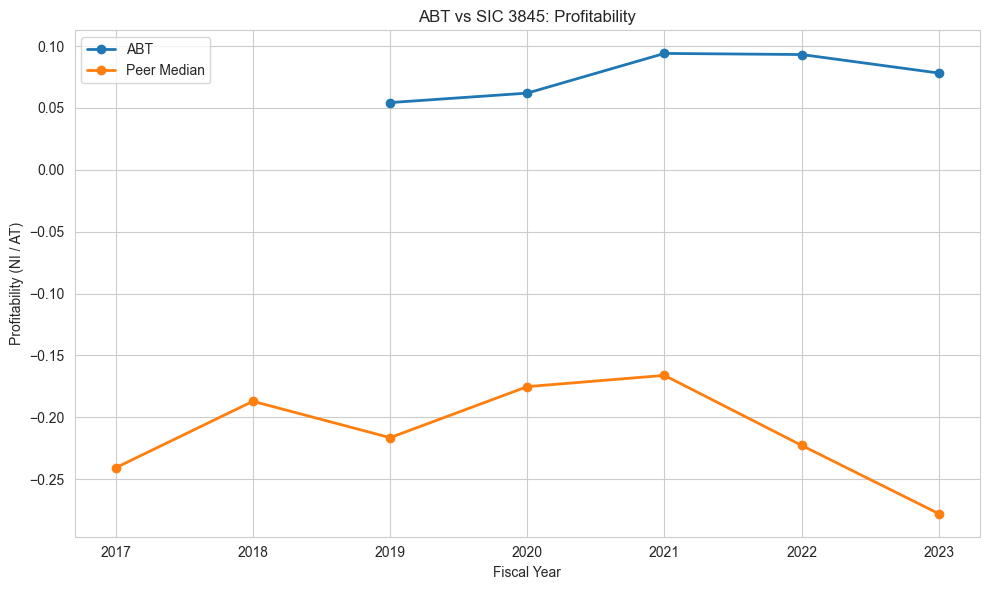

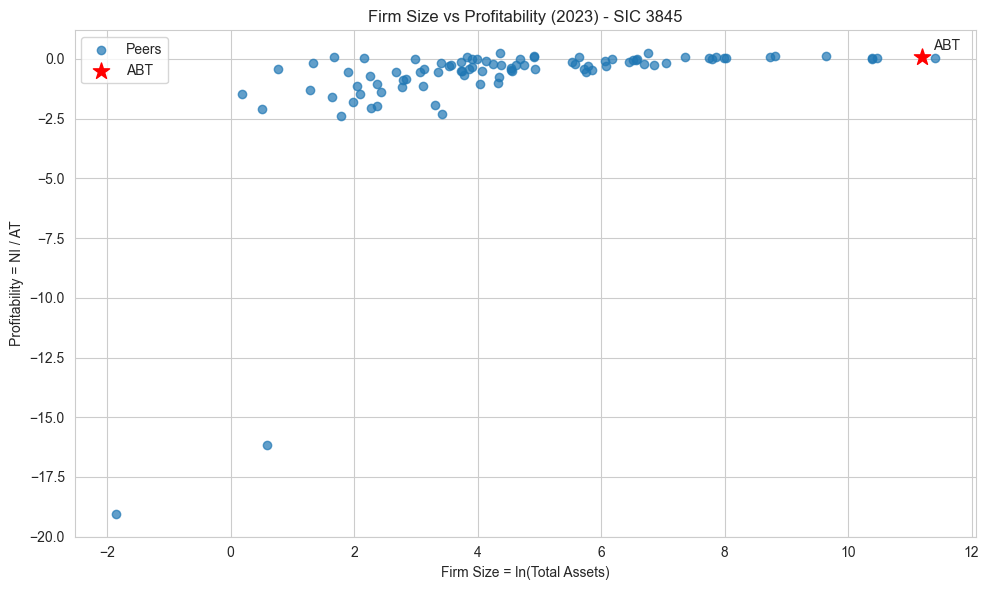


Saved: ABT_vs_SIC3845_improved_comparison.csv


In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Copy and clean data
# =========================
data = df.copy()

data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['conm'] = data['conm'].astype(str).str.strip()
data['sic'] = data['sic'].astype(str).str.strip()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

for col in ['sale', 'ni', 'at', 'firm_size', 'profitability']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['tic', 'fyear'])

# =========================
# 2. Recalculate firm_size and profitability safely
# =========================
# firm size = ln(total assets), only if at > 0
data['firm_size'] = np.where(data['at'] > 0, np.log(data['at']), np.nan)

# profitability = ni / at, only if at > 0
data['profitability'] = np.where(data['at'] > 0, data['ni'] / data['at'], np.nan)

# =========================
# 3. Winsorize profitability to reduce extreme outliers
# =========================
def winsorize_series(s, lower=0.01, upper=0.99):
    lower_val = s.quantile(lower)
    upper_val = s.quantile(upper)
    return s.clip(lower=lower_val, upper=upper_val)

data['profitability_w'] = data.groupby('fyear')['profitability'].transform(
    lambda x: winsorize_series(x.dropna()) if x.notna().sum() > 0 else x
)

# 如果 transform 后有些行没对齐，可以再保险一点：
mask = data['profitability_w'].isna() & data['profitability'].notna()
data.loc[mask, 'profitability_w'] = data.loc[mask, 'profitability']

# =========================
# 4. Find ABT and choose industry
# =========================
abt_rows = data[data['tic'] == 'ABT']
if abt_rows.empty:
    raise ValueError("ABT is not found in your dataframe.")

abt_sic = abt_rows['sic'].dropna().iloc[0]
abt_prefix2 = abt_sic[:2]

same_sic = data[data['sic'] == abt_sic].copy()
broad_industry = data[data['sic'].str.startswith(abt_prefix2, na=False)].copy()

same_sic_peer_count = same_sic[same_sic['tic'] != 'ABT']['tic'].nunique()

if same_sic_peer_count >= 5:
    industry_df = same_sic.copy()
    industry_label = f"SIC {abt_sic}"
else:
    industry_df = broad_industry.copy()
    industry_label = f"{abt_prefix2}xx industry"

abt_df = industry_df[industry_df['tic'] == 'ABT'].copy()
peer_df = industry_df[industry_df['tic'] != 'ABT'].copy()

print("Using peer group:", industry_label)
print("Peer companies excluding ABT:", peer_df['tic'].nunique())

# =========================
# 5. Compute yearly values
# For peers:
# - sale: mean
# - ni: mean
# - firm_size: mean
# - profitability: median (more robust)
# =========================
peer_yearly = (
    peer_df.groupby('fyear')
    .agg(
        sale_peer=('sale', 'mean'),
        ni_peer=('ni', 'mean'),
        firm_size_peer=('firm_size', 'mean'),
        profitability_peer=('profitability_w', 'median')
    )
    .reset_index()
)

abt_yearly = (
    abt_df.groupby('fyear')
    .agg(
        sale_abt=('sale', 'mean'),
        ni_abt=('ni', 'mean'),
        firm_size_abt=('firm_size', 'mean'),
        profitability_abt=('profitability_w', 'mean')
    )
    .reset_index()
)

comparison_df = pd.merge(abt_yearly, peer_yearly, on='fyear', how='outer').sort_values('fyear')

print("\n===== Improved ABT vs Peer Table =====")
print(comparison_df)

# =========================
# 6. Plot style
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# =========================
# 7. Plot Sales
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['sale_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['sale_peer'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Sales')
plt.xlabel('Fiscal Year')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. Plot Net Income
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['ni_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['ni_peer'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Net Income')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Plot Profitability
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['profitability_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['profitability_peer'], marker='o', linewidth=2, label='Peer Median')
plt.title(f'ABT vs {industry_label}: Profitability')
plt.xlabel('Fiscal Year')
plt.ylabel('Profitability (NI / AT)')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 10. Scatter plot for latest year
# =========================
latest_year = int(industry_df['fyear'].dropna().max())
scatter_df = industry_df[industry_df['fyear'] == latest_year].copy()

plt.figure(figsize=(10, 6))
peer_scatter = scatter_df[scatter_df['tic'] != 'ABT']
abt_scatter = scatter_df[scatter_df['tic'] == 'ABT']

plt.scatter(
    peer_scatter['firm_size'],
    peer_scatter['profitability_w'],
    alpha=0.7,
    label='Peers'
)

if not abt_scatter.empty:
    plt.scatter(
        abt_scatter['firm_size'],
        abt_scatter['profitability_w'],
        color='red',
        s=150,
        marker='*',
        label='ABT'
    )
    for _, row in abt_scatter.iterrows():
        plt.annotate(
            'ABT',
            (row['firm_size'], row['profitability_w']),
            textcoords='offset points',
            xytext=(8, 5),
            ha='left'
        )

plt.title(f'Firm Size vs Profitability ({latest_year}) - {industry_label}')
plt.xlabel('Firm Size = ln(Total Assets)')
plt.ylabel('Profitability = NI / AT')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. Save results
# =========================
comparison_df.to_csv("ABT_vs_SIC3845_improved_comparison.csv", index=False)
print("\nSaved: ABT_vs_SIC3845_improved_comparison.csv")

## 3.1 Peer Group Selection
### Abbott Laboratories (ABT) is compared with firms in the same four-digit SIC industry classification (SIC 3845). This peer group is appropriate because the dataset includes a sufficiently large number of comparable firms, with 104 peer companies excluding ABT. As a result, the analysis adopts a narrow industry definition rather than a broader two-digit SIC classification.
## 3.2 Comparative Performance
### The results show that ABT consistently outperforms the average peer firm in terms of scale and earnings. Its sales are substantially higher than the peer-group average throughout the sample period, indicating that Abbott operates at a much larger scale than most firms in the same industry. A similar pattern is observed for net income, where ABT remains well above the industry average in each year.
## 3.3 Profitability and Market Position
### In terms of profitability, Abbott also performs favorably relative to its peers. Although peer-group profitability may be affected by extreme observations, the overall pattern suggests that ABT maintains a stronger and more stable financial position than the typical firm in SIC 3845. This interpretation is further supported by the firm size–profitability scatter plot, in which Abbott is positioned in the upper-right region, indicating both large size and relatively high profitability.
## 3.4 Conclusion
### Overall, the evidence suggests that Abbott Laboratories is not only one of the largest firms in its industry, but also one of the strongest financial performers within the SIC 3845 peer group.
## Figure Captions
### Figure 1
#### Sales of ABT versus the average of SIC 3845 peer firms, 2018–2023.
#### The figure shows that Abbott Laboratories reports substantially higher sales than the average peer firm throughout the sample period.
### Figure 2
#### Net income of ABT versus the average of SIC 3845 peer firms, 2018–2023.
#### Abbott’s net income remains consistently above the industry average, indicating stronger earnings performance relative to peers.
### Figure 3
#### Profitability of ABT versus SIC 3845 peer firms, 2018–2023.
#### The figure suggests that ABT maintains stronger profitability than the typical peer firm, although peer-group values may be sensitive to outliers.
### Figure 4
#### Firm size and profitability in SIC 3845, with ABT highlighted, 2023.
#### Abbott is located in the upper-right area of the distribution, indicating both large firm size and relatively high profitability compared with other firms in the same industry.